### ML2 GRADED ASSESSMENT

### 1.	Data Understanding (5 marks)

a.	Read the dataset (tab, csv, xls, txt, inbuilt dataset). Print thenumber of rows, cols and types of variables (continuous, categorical etc.)? (1 MARK)

b.	Calculate five-point summary for numerical variables (1 MARK)

c.	Summarize observations for categorical variables – no. of categories, % observations in each category. (1 mark)

d.	Check for defects in the data such as missing values, outliers, etc and also check for class imbalance. (2 marks)



In [39]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

##### a.	Read the dataset (tab, csv, xls, txt, inbuilt dataset). What are the number of rows and no. of cols & types of variables (continuous, categorical etc.)? (1 MARK)

In [40]:
data = pd.read_csv('sl_data.csv')

In [41]:
data.head(10)

,Patient_ID,Skin_treatment,F1,F2,F3,F4,F5,F6,F7,F8,...,F21,F22,F23,F24,F25,F26,F27,F28,F29,F30
0,1,N,10.729641,10.099752,125.903083,457.940042,0.063236,0.023311,0.176994,0.016436,...,17.739020,26.182043,92.652045,642.495423,0.181766,0.267158,0.065338,0.003512,0.277782,0.078103
1,2,N,9.447797,17.314982,92.407802,557.593030,0.109878,0.158177,0.072635,0.002340,...,14.791384,25.337883,78.690352,335.516677,0.140064,0.071308,0.038919,0.084125,0.305742,0.066928
2,3,Y,5.959793,11.681181,61.210054,1223.331231,0.134512,0.025881,0.145682,0.065860,...,24.200978,33.397013,208.721687,1994.281664,0.204021,0.204351,0.041159,0.220559,0.181232,0.059967
3,4,N,13.754506,12.027445,106.782452,282.866565,0.083974,0.013250,0.017845,0.008735,...,15.382723,29.830480,116.052575,567.700777,0.196982,0.208801,0.245444,0.065607,0.191249,0.089119
4,5,N,7.258033,12.770999,96.949392,563.059258,0.105484,0.012277,0.027942,0.008558,...,16.089505,22.752852,124.062734,385.824932,0.193448,0.278978,0.060420,0.037078,0.334095,0.063165
5,6,Y,14.315611,9.696807,127.639190,1469.457205,0.155924,0.117283,0.180296,0.020335,...,18.441146,26.279213,133.021943,807.403810,0.188730,0.542684,0.072113,0.130085,0.289895,0.101960
6,7,N,8.505469,13.388362,115.780122,511.600250,0.097374,0.051660,0.022756,0.009784,...,13.963577,29.952143,102.457469,505.389872,0.092125,0.222819,0.148774,0.011998,0.347601,0.070311
7,8,Y,23.135739,13.154397,133.842589,678.029934,0.099874,0.140622,0.128697,0.072058,...,27.279630,29.631698,118.322774,2774.515074,0.185075,0.772186,0.174249,0.146611,0.212587,0.064980
8,9,N,7.950201,13.361050,84.258515,674.767677,0.072133,0.031046,0.014426,0.007450,...,34.779724,15.041113,95.071539,392.297684,0.135499,0.212350,0.348234,0.078110,0.220488,0.051433
9,10,Y,15.537828,11.717711,127.020856,743.199671,0.108072,0.057614,0.024049,0.048055,...,21.486748,33.294325,183.016317,725.515888,0.157388,0.684818,0.429485,0.077231,0.267752,0.084545


In [42]:
data.shape

(1008, 32)

In [43]:
data.columns

Index(['Patient_ID', 'Skin_treatment', 'F1', 'F2', 'F3', 'F4', 'F5', 'F6',
       'F7', 'F8', 'F9', 'F10', 'F11', 'F12', 'F13', 'F14', 'F15', 'F16',
       'F17', 'F18', 'F19', 'F20', 'F21', 'F22', 'F23', 'F24', 'F25', 'F26',
       'F27', 'F28', 'F29', 'F30'],
      dtype='object')

In [44]:
# removing id and unnamed: 32 column which is not necessary for our model
data = data.drop(['Patient_ID'],axis = 1)

In [45]:
data.head(10)

,Skin_treatment,F1,F2,F3,F4,F5,F6,F7,F8,F9,...,F21,F22,F23,F24,F25,F26,F27,F28,F29,F30
0,N,10.729641,10.099752,125.903083,457.940042,0.063236,0.023311,0.176994,0.016436,0.309283,...,17.739020,26.182043,92.652045,642.495423,0.181766,0.267158,0.065338,0.003512,0.277782,0.078103
1,N,9.447797,17.314982,92.407802,557.593030,0.109878,0.158177,0.072635,0.002340,0.218042,...,14.791384,25.337883,78.690352,335.516677,0.140064,0.071308,0.038919,0.084125,0.305742,0.066928
2,Y,5.959793,11.681181,61.210054,1223.331231,0.134512,0.025881,0.145682,0.065860,0.191499,...,24.200978,33.397013,208.721687,1994.281664,0.204021,0.204351,0.041159,0.220559,0.181232,0.059967
3,N,13.754506,12.027445,106.782452,282.866565,0.083974,0.013250,0.017845,0.008735,0.166689,...,15.382723,29.830480,116.052575,567.700777,0.196982,0.208801,0.245444,0.065607,0.191249,0.089119
4,N,7.258033,12.770999,96.949392,563.059258,0.105484,0.012277,0.027942,0.008558,0.199368,...,16.089505,22.752852,124.062734,385.824932,0.193448,0.278978,0.060420,0.037078,0.334095,0.063165
5,Y,14.315611,9.696807,127.639190,1469.457205,0.155924,0.117283,0.180296,0.020335,0.231408,...,18.441146,26.279213,133.021943,807.403810,0.188730,0.542684,0.072113,0.130085,0.289895,0.101960
6,N,8.505469,13.388362,115.780122,511.600250,0.097374,0.051660,0.022756,0.009784,0.214651,...,13.963577,29.952143,102.457469,505.389872,0.092125,0.222819,0.148774,0.011998,0.347601,0.070311
7,Y,23.135739,13.154397,133.842589,678.029934,0.099874,0.140622,0.128697,0.072058,0.287168,...,27.279630,29.631698,118.322774,2774.515074,0.185075,0.772186,0.174249,0.146611,0.212587,0.064980
8,N,7.950201,13.361050,84.258515,674.767677,0.072133,0.031046,0.014426,0.007450,0.316410,...,34.779724,15.041113,95.071539,392.297684,0.135499,0.212350,0.348234,0.078110,0.220488,0.051433
9,Y,15.537828,11.717711,127.020856,743.199671,0.108072,0.057614,0.024049,0.048055,0.219241,...,21.486748,33.294325,183.016317,725.515888,0.157388,0.684818,0.429485,0.077231,0.267752,0.084545


##### b.	Calculate five-point summary for numerical variables (1 MARK)

In [46]:
data.describe()

,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,...,F21,F22,F23,F24,F25,F26,F27,F28,F29,F30
count,1007.000000,1007.000000,1006.000000,1008.000000,1006.000000,1008.000000,1007.000000,1007.000000,1007.000000,1007.000000,...,1008.000000,1008.000000,1008.000000,1008.000000,1008.000000,1008.000000,1008.000000,1008.000000,1008.000000,1008.000000
mean,12.559906,14.570835,100.306961,752.996970,0.099885,0.077377,0.050885,0.033116,0.227398,0.063349,...,16.972966,25.936423,125.897018,551.940076,0.152804,0.276515,0.184987,0.089401,0.263358,0.074210
std,3.886917,4.148864,28.998768,380.141070,0.020030,0.042208,0.057187,0.035179,0.041402,0.008472,...,6.264067,6.674752,48.061970,458.210733,0.033373,0.194750,0.160285,0.064984,0.069820,0.019388
min,5.753360,6.407277,38.728787,93.157800,0.050752,0.000202,0.000049,0.000019,0.109000,0.045280,...,6.691088,8.792066,37.237149,1.886849,0.077512,0.000165,0.000333,0.000186,0.075547,0.026947
25%,9.778168,11.453264,80.076676,501.263509,0.085531,0.046498,0.013438,0.007599,0.200184,0.057123,...,12.572423,21.282321,90.948109,246.335394,0.129968,0.142274,0.059360,0.034905,0.212662,0.060734
50%,11.906741,14.019957,96.948771,656.942181,0.099214,0.072006,0.028263,0.018810,0.222983,0.062521,...,15.376920,25.590731,113.419386,438.013333,0.150353,0.233158,0.140857,0.081404,0.255371,0.071194
75%,14.673804,17.077883,113.847418,931.436517,0.113390,0.102346,0.066840,0.050331,0.245806,0.068134,...,19.798613,30.310183,158.802966,709.614695,0.176374,0.369083,0.272310,0.125346,0.304564,0.083195
max,34.766907,30.856862,225.169931,3174.048902,0.197330,0.260403,0.403034,0.203582,0.341423,0.120604,...,36.658121,56.298122,311.546561,3054.569160,0.240933,1.198900,0.934504,0.318810,0.611810,0.166937


##### c.	Summarize observations for categorical variables – no. of categories, % observations in each category. (1 mark)

In [47]:
# for skintreatment do value counts

In [48]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1008 entries, 0 to 1007
Data columns (total 31 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Skin_treatment  1008 non-null   object 
 1   F1              1007 non-null   float64
 2   F2              1007 non-null   float64
 3   F3              1006 non-null   float64
 4   F4              1008 non-null   float64
 5   F5              1006 non-null   float64
 6   F6              1008 non-null   float64
 7   F7              1007 non-null   float64
 8   F8              1007 non-null   float64
 9   F9              1007 non-null   float64
 10  F10             1007 non-null   float64
 11  F11             1003 non-null   float64
 12  F12             1008 non-null   float64
 13  F13             1008 non-null   float64
 14  F14             1008 non-null   float64
 15  F15             1008 non-null   float64
 16  F16             1008 non-null   float64
 17  F17             1008 non-null   f

##### d.	Check for defects in the data such as missing values, null, outliers, etc and also check for class imbalance. (2 marks)

In [49]:
# As our dataset is balanced (around 60-40 ratio), there is no need to balance our data
data.Skin_treatment.value_counts(normalize = True)

Skin_treatment
N    0.632937
Y    0.367063
Name: proportion, dtype: float64

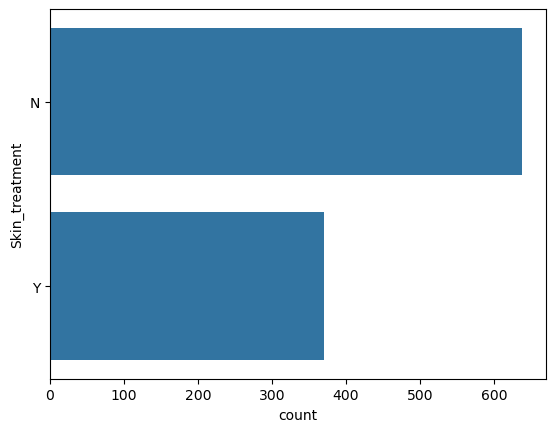

In [50]:
#visualize the count
sns.countplot(data.Skin_treatment,label="count")
plt.show()

In [51]:
data.columns

Index(['Skin_treatment', 'F1', 'F2', 'F3', 'F4', 'F5', 'F6', 'F7', 'F8', 'F9',
       'F10', 'F11', 'F12', 'F13', 'F14', 'F15', 'F16', 'F17', 'F18', 'F19',
       'F20', 'F21', 'F22', 'F23', 'F24', 'F25', 'F26', 'F27', 'F28', 'F29',
       'F30'],
      dtype='object')

In [52]:
data.isnull().sum()

Skin_treatment    0
F1                1
F2                1
F3                2
F4                0
F5                2
F6                0
F7                1
F8                1
F9                1
F10               1
F11               5
F12               0
F13               0
F14               0
F15               0
F16               0
F17               0
F18               0
F19               0
F20               0
F21               0
F22               0
F23               0
F24               0
F25               0
F26               0
F27               0
F28               0
F29               0
F30               0
dtype: int64

* Now we can see that there are missing values in the dataset.

In [53]:
data.dropna(inplace=True)

In [54]:
data.isnull().sum()

Skin_treatment    0
F1                0
F2                0
F3                0
F4                0
F5                0
F6                0
F7                0
F8                0
F9                0
F10               0
F11               0
F12               0
F13               0
F14               0
F15               0
F16               0
F17               0
F18               0
F19               0
F20               0
F21               0
F22               0
F23               0
F24               0
F25               0
F26               0
F27               0
F28               0
F29               0
F30               0
dtype: int64

In [55]:
# Now there are no missing values.

#### b.	Do variables have outliers? 


In [56]:
df.hist / df.skew() 

NameError: name 'df' is not defined

In [57]:
fig, (a,b)= plt.subplots(1,2,figsize=(20,6))
sns.boxplot(y='F2',x='Skin_treatment',data=data,ax=a)
sns.boxplot(y='F3',x='Skin_treatment',data=data,ax=b)

<Axes: xlabel='Skin_treatment', ylabel='F3'>

### 2.	Data Preparation (10 marks)

a.	Fix the defects found above and do appropriate treatment if required. (3 marks)

b.	Visualize the data using relevant plots. Find out the variables which are highly correlated with Target? (5 marks)

c.	Do you want to exclude some variables from the model based on this analysis? What other actions will you take? (4 marks)

d.	Split dataset into train and test (70:30). Are both train and test representative of the overall data? How would you ascertain this statistically? (3 marks)


In [58]:
df1 = data[(data['F2']>data['F2'].quantile(0.75)) 
              & (data['F3']> data['F3'].quantile(0.75))]
df1.head()

,Skin_treatment,F1,F2,F3,F4,F5,F6,F7,F8,F9,...,F21,F22,F23,F24,F25,F26,F27,F28,F29,F30
10,Y,14.434185,19.968472,142.724666,1771.523777,0.098648,0.066754,0.000777,0.060701,0.314500,...,20.868294,26.508597,161.470816,124.405361,0.209607,0.598267,0.255761,0.191470,0.235848,0.065213
11,Y,23.499796,20.156731,114.914154,1563.910108,0.072952,0.073225,0.053535,0.027296,0.239481,...,22.184467,36.261206,215.814699,2047.174329,0.196339,0.097493,0.244154,0.020212,0.238544,0.047811
15,Y,28.801665,22.621923,143.755188,537.430010,0.102910,0.043924,0.139340,0.017461,0.316605,...,25.015834,14.688282,201.921273,253.009757,0.152350,0.120123,0.036840,0.075612,0.266366,0.028756
36,N,10.472627,21.343975,123.280614,370.803882,0.081927,0.066160,0.103821,0.021126,0.237786,...,13.724028,32.308074,103.608017,401.670625,0.187239,0.114300,0.211575,0.133877,0.259211,0.070336
37,N,14.103078,17.265938,127.789244,585.892905,0.083418,0.017614,0.018447,0.004411,0.205398,...,16.182244,25.682996,110.453890,215.654772,0.172079,0.156994,0.475291,0.110456,0.184092,0.086014


In [59]:
from sklearn.preprocessing import PowerTransformer
pt= PowerTransformer()
df_new= pd.DataFrame(pt.fit_transform(data), columns=data.columns)

ValueError: could not convert string to float: 'N'

In [60]:
fig, (a,b)= plt.subplots(1,2,figsize=(20,6))
sns.boxplot(y='F2',x='Skin_treatment',data=df1,ax=a)
sns.boxplot(y='F3',x='Skin_treatment',data=df1,ax=b)

<Axes: xlabel='Skin_treatment', ylabel='F3'>

##### b.	Visualize the data using relevant plots. Find out the variables which are highly correlated with Target? (5 marks)

In [61]:
#correlation map
df1.select_dtypes(include=['int64', 'float64']).corr()

,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,...,F21,F22,F23,F24,F25,F26,F27,F28,F29,F30
F1,1.000000,-0.136201,-0.196106,0.157991,0.072628,-0.087569,0.299411,0.164751,0.244126,0.052549,...,0.400905,-0.189127,0.322124,0.168023,0.024581,0.055223,-0.024830,0.251799,0.128330,-0.101009
F2,-0.136201,1.000000,0.115279,-0.082103,-0.133884,-0.244810,-0.094743,-0.009200,-0.136118,-0.051356,...,-0.125450,0.027988,-0.350631,-0.047098,-0.077030,-0.216791,-0.089997,-0.199659,-0.168850,-0.077215
F3,-0.196106,0.115279,1.000000,0.128306,0.257782,0.052002,0.057521,0.045217,-0.089623,0.021001,...,0.002656,0.063198,0.195540,0.090053,-0.165008,0.204905,0.202676,-0.047133,0.012009,-0.089997
F4,0.157991,-0.082103,0.128306,1.000000,-0.007051,0.195857,-0.014986,0.110322,0.138372,-0.070806,...,0.128860,0.153624,0.192116,0.122502,-0.025369,0.321848,0.321695,0.078620,0.056018,-0.225648
F5,0.072628,-0.133884,0.257782,-0.007051,1.000000,-0.215374,0.075232,-0.036775,0.101679,0.065932,...,-0.007844,0.061476,0.003901,0.000706,0.172953,0.029272,-0.125675,-0.012332,0.121445,0.054670
F6,-0.087569,-0.244810,0.052002,0.195857,-0.215374,1.000000,0.079165,0.111553,0.124857,0.252820,...,0.062755,0.128103,0.165854,0.129901,0.140310,-0.044939,-0.000875,0.193118,0.026714,0.032686
F7,0.299411,-0.094743,0.057521,-0.014986,0.075232,0.079165,1.000000,0.046554,0.191817,0.091897,...,-0.005425,-0.073254,0.135251,-0.103188,0.022221,0.165108,-0.131579,0.013132,0.221791,-0.203965
F8,0.164751,-0.009200,0.045217,0.110322,-0.036775,0.111553,0.046554,1.000000,-0.004987,0.023084,...,0.400134,0.113428,0.334924,0.222465,-0.046763,0.435050,-0.023153,0.297492,-0.015820,0.033909
F9,0.244126,-0.136118,-0.089623,0.138372,0.101679,0.124857,0.191817,-0.004987,1.000000,0.191200,...,0.230065,0.021793,0.428671,0.132212,0.214949,0.184723,-0.293112,0.172025,-0.036350,-0.182405
F10,0.052549,-0.051356,0.021001,-0.070806,0.065932,0.252820,0.091897,0.023084,0.191200,1.000000,...,0.101688,0.074794,0.016828,-0.210533,0.310798,-0.113013,0.027487,-0.042131,0.059382,-0.056890


In [62]:
#correlation map
f,ax = plt.subplots(figsize=(18, 18))
sns.heatmap(data.select_dtypes(include='number').corr(), annot=True, linewidths=.5, fmt= '.1f',ax=ax)
# plt.show()

<Axes: >

##### c.	Do you want to exclude some variables from the model based on this analysis? What other actions will you take? (4 marks)

In [63]:
data.Skin_treatment.value_counts()


Skin_treatment
N    633
Y    366
Name: count, dtype: int64

In [64]:
# Mapping our target variable to 1 and 0
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data['Skin_treatment'] = le.fit_transform(data['Skin_treatment'])

In [65]:
data.Skin_treatment.value_counts(normalize=True)

Skin_treatment
0    0.633634
1    0.366366
Name: proportion, dtype: float64

In [66]:
data.Skin_treatment.value_counts()


Skin_treatment
0    633
1    366
Name: count, dtype: int64

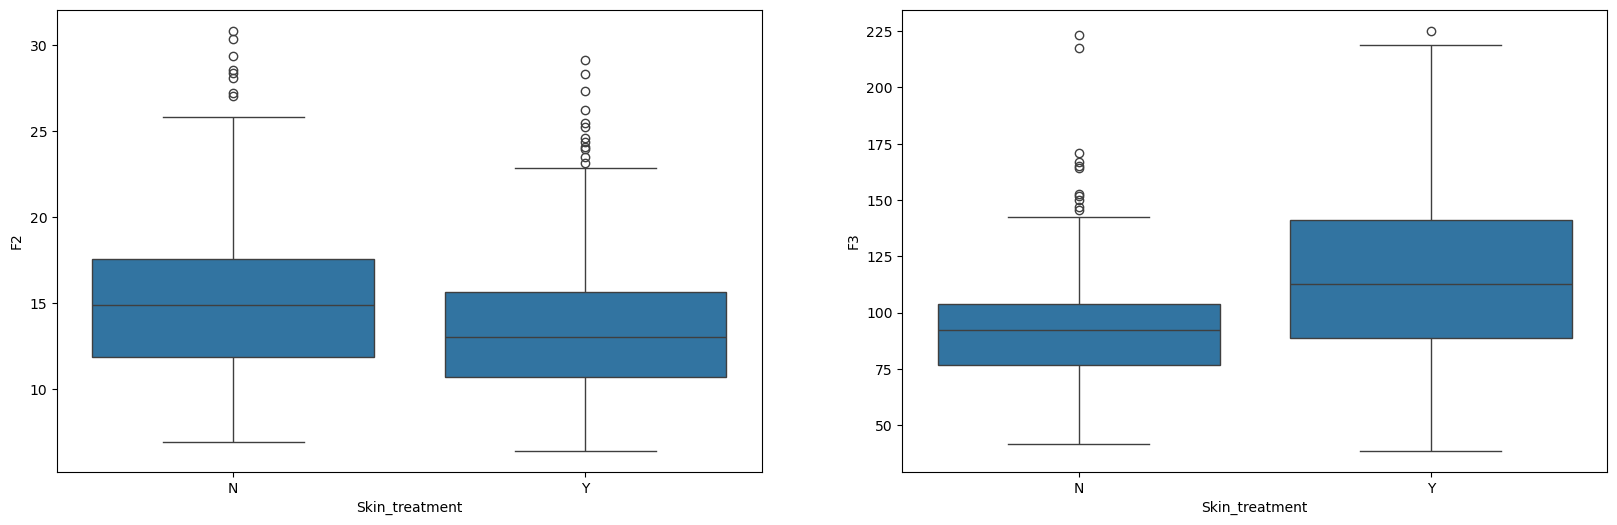

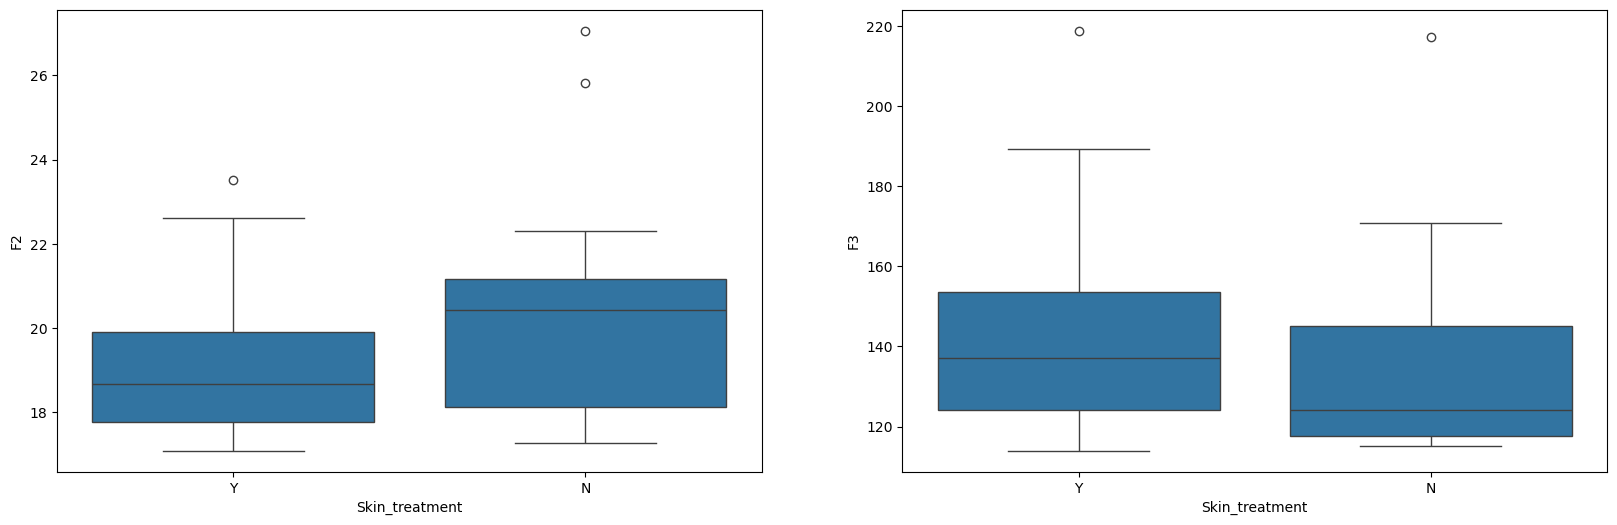

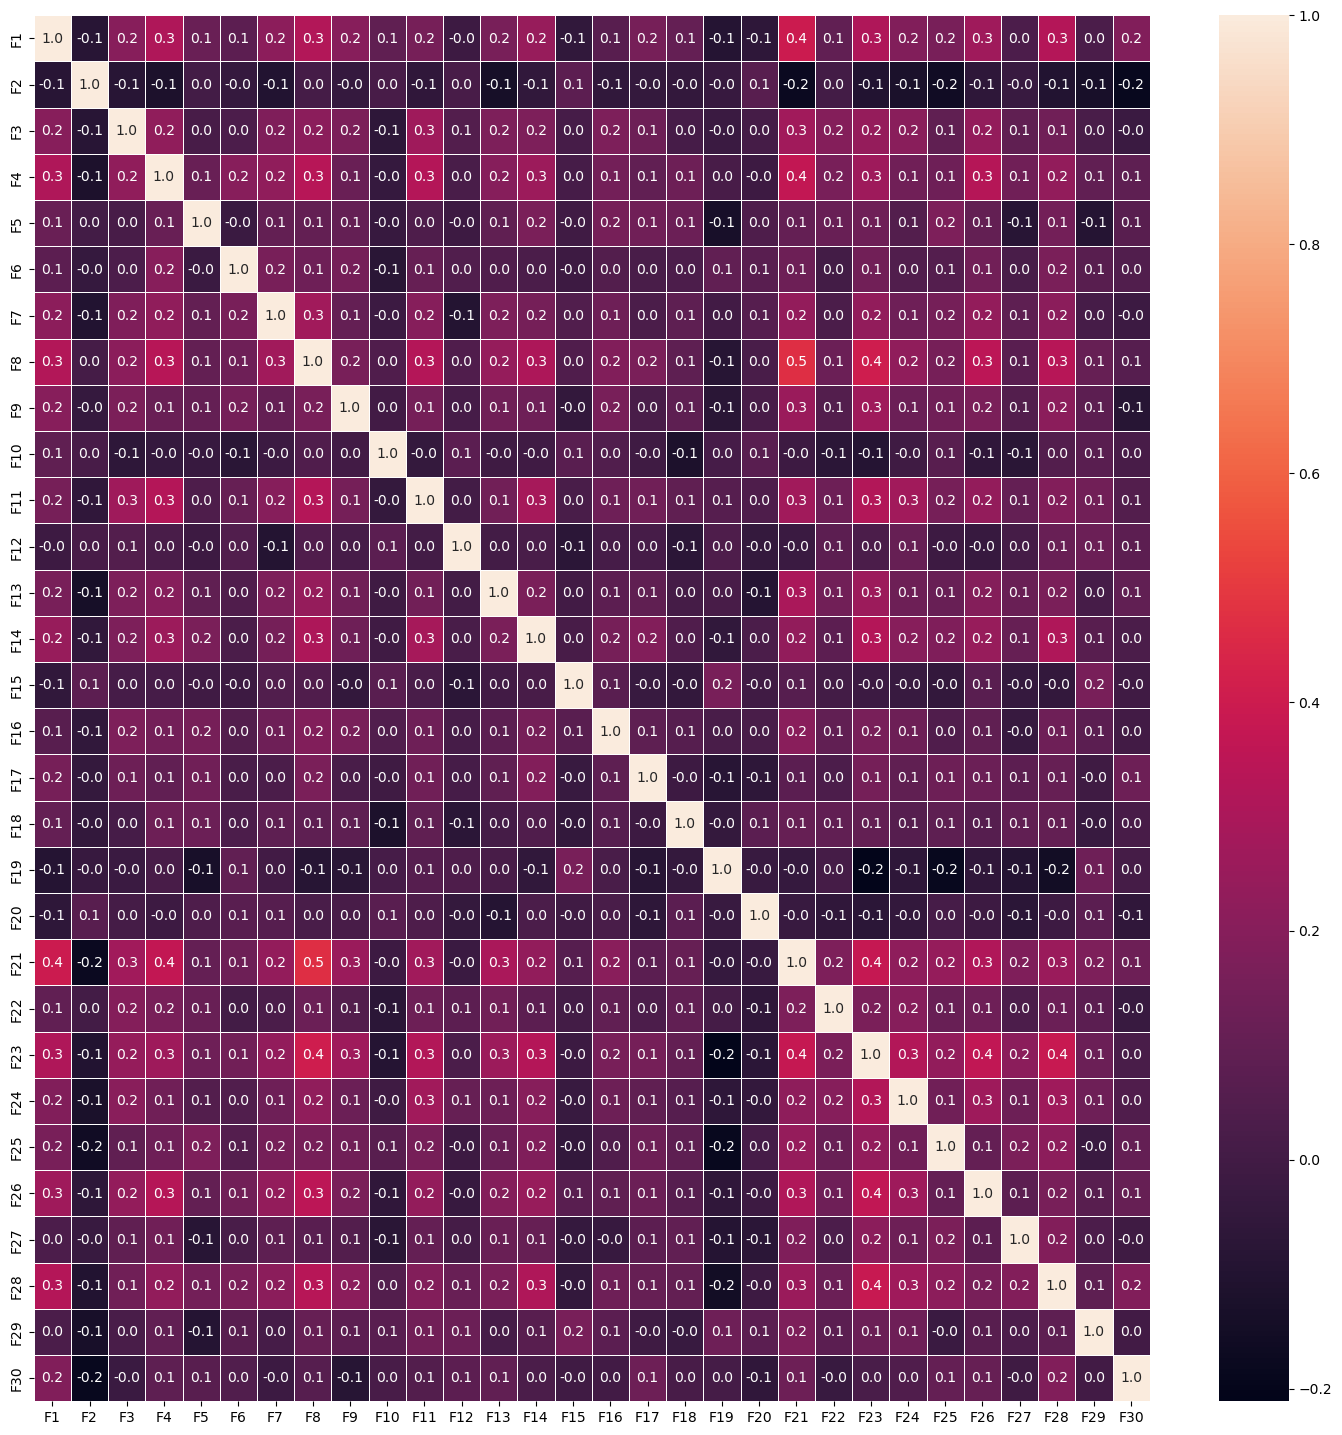

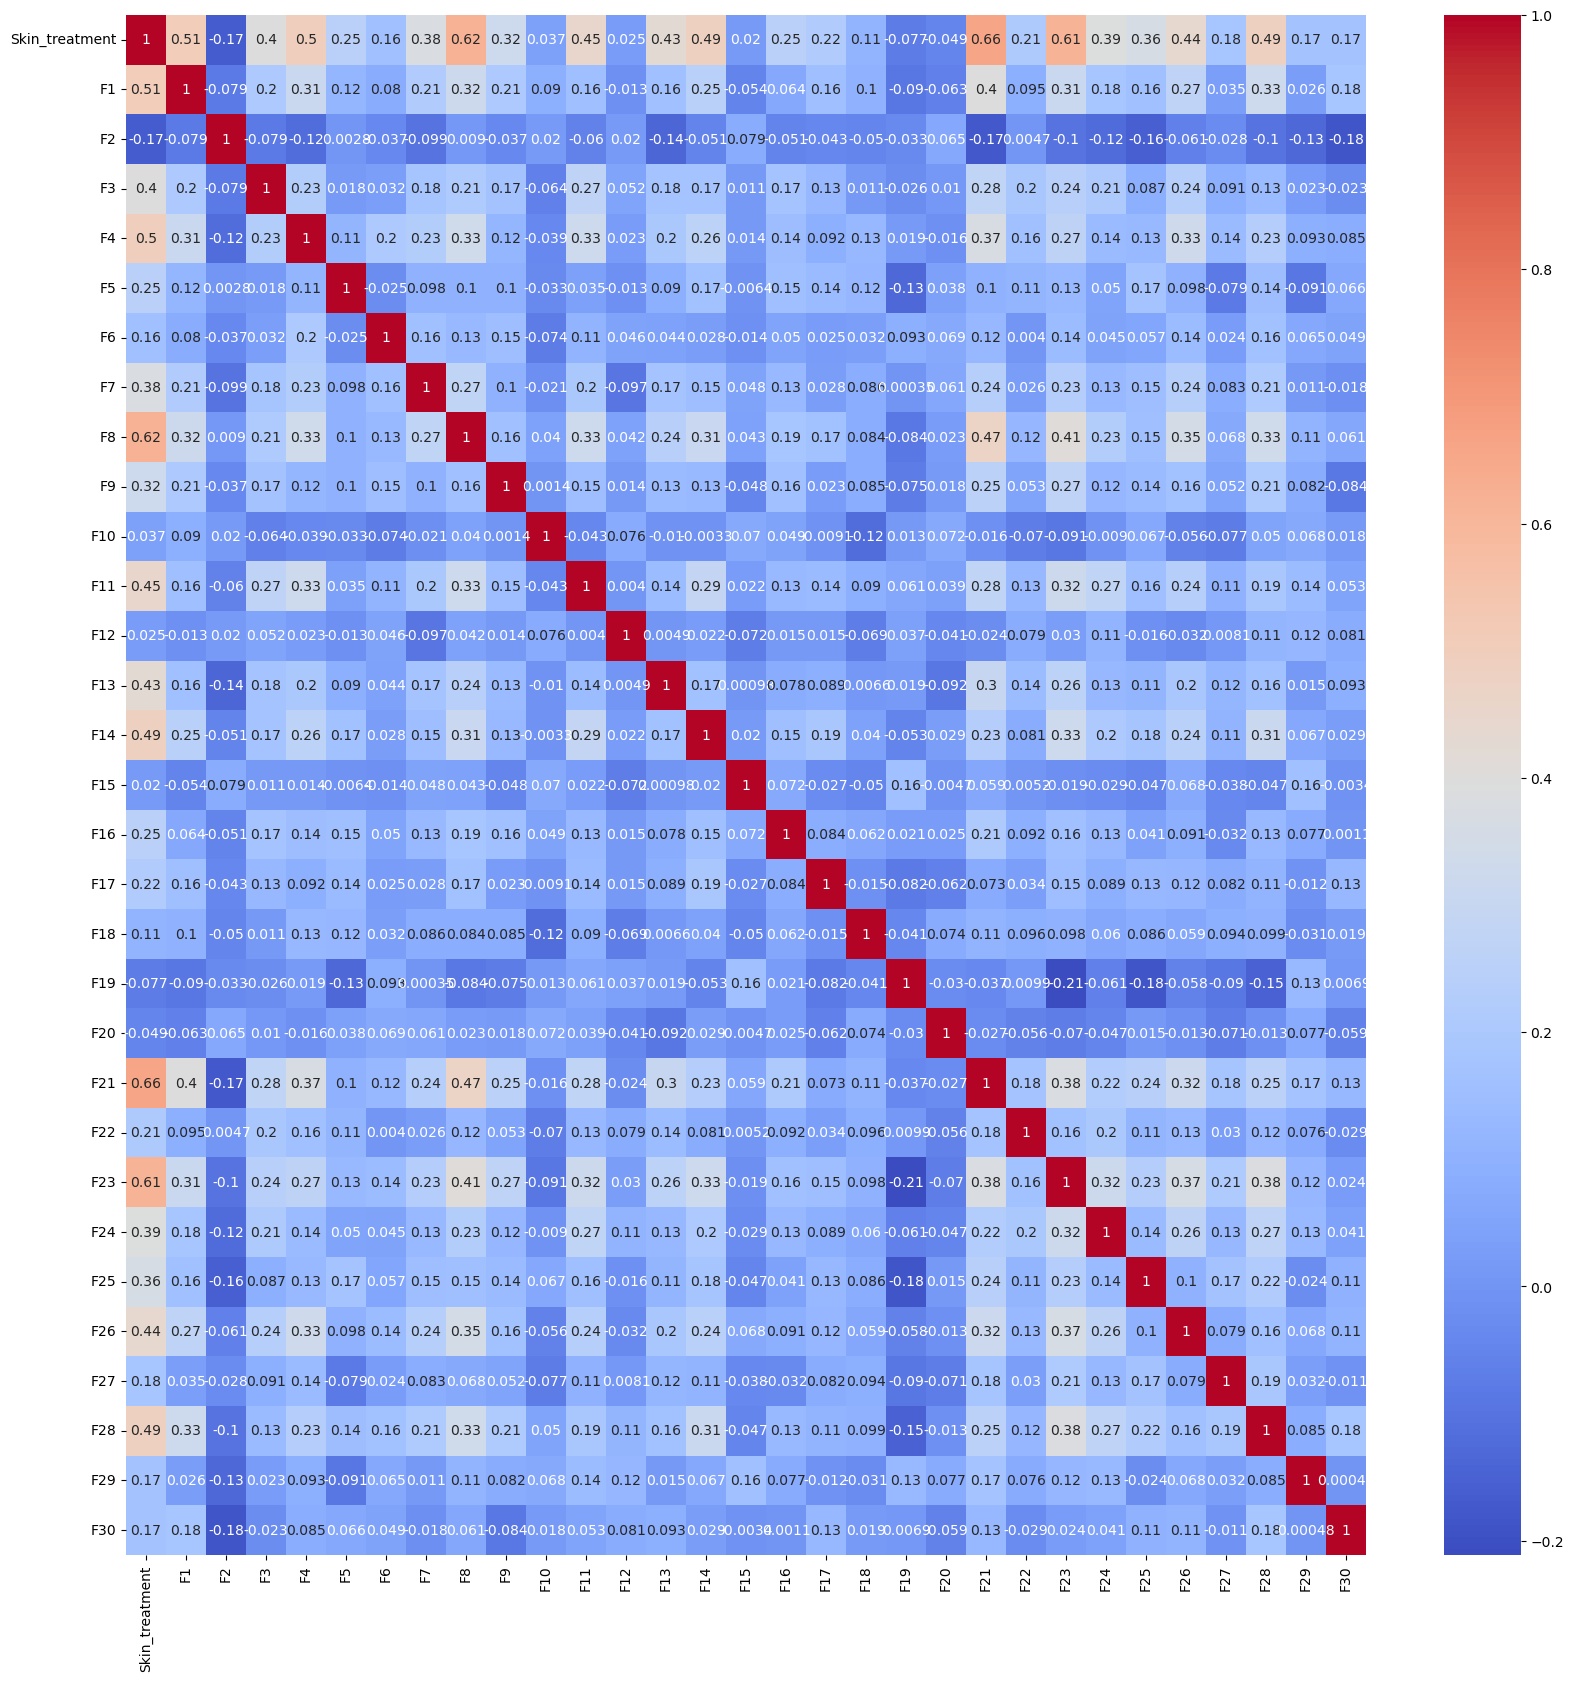

In [67]:
# Finding correlation among features using sns' heatmap
plt.figure(figsize=(20,20))
sns.heatmap(data.corr(),annot=True,cmap='coolwarm')

# # Use lowercase 'f' in figure
# plt.figure(figsize=(20,20))

# # Plot the heatmap
# sns.heatmap(data.corr(), annot=True, cmap='coolwarm')

# Explicitly call show
plt.show()

In [68]:
# removing features that are less correlated with our target variable
data.corr().Skin_treatment[data.corr().Skin_treatment<=0.3]

F2    -0.167466
F5     0.252038
F6     0.158102
F10    0.037232
F12    0.024744
F15    0.020437
F16    0.247844
F17    0.218310
F18    0.108849
F19   -0.076855
F20   -0.049039
F22    0.206491
F27    0.184539
F29    0.169351
F30    0.168186
Name: Skin_treatment, dtype: float64

In [69]:
#less_corr = data.corr().diagnosis[data.corr().diagnosis<=0.2].index
less_corr = data.corr().Skin_treatment[data.corr().Skin_treatment<=0.3].index

In [70]:
less_corr = list(less_corr)+ ['Skin_treatment']

In [71]:
data = data[less_corr]

In [72]:
data.shape

(999, 16)

In [73]:
# Standardizing our features except target variable
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import StandardScaler
stand_scale = data.drop(['Skin_treatment'],axis = 1)
col_trans = make_column_transformer(
            (StandardScaler(), stand_scale.columns),
            remainder = 'passthrough')

##### d.	Split dataset into train and test (70:30). Are both train and test representative of the overall data? How would you ascertain this statistically? (3 marks)

In [74]:
from sklearn.model_selection import train_test_split
X = data.drop(['Skin_treatment'], axis = 1)
y = data['Skin_treatment']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 0)

In [75]:
col_trans.fit_transform(X_train)

array([[ 0.23961391, -1.1354538 , -1.31084571, ..., -0.01260799,
        -0.88755195, -0.52887152],
       [ 0.44763998,  0.03713699, -0.41736386, ...,  0.71657126,
        -0.32504715, -0.70802911],
       [-0.42581808,  0.47792072,  0.43729592, ..., -0.71204946,
        -0.6364423 , -0.21848622],
       ...,
       [ 0.55927119, -0.41456711, -1.2403306 , ..., -0.51268369,
        -0.64615366, -0.02706629],
       [-1.08977119, -0.6042238 , -0.29130511, ..., -0.28175619,
        -0.06713115, -0.87811734],
       [-1.25046907, -0.57279904,  1.30875406, ..., -1.0729161 ,
         0.85966558, -0.94932476]])

In [76]:
X.head()

,F2,F5,F6,F10,F12,F15,F16,F17,F18,F19,F20,F22,F27,F29,F30
0,10.099752,0.063236,0.023311,0.052966,0.804112,0.012763,0.024450,0.013419,0.019874,0.052614,0.000223,26.182043,0.065338,0.277782,0.078103
1,17.314982,0.109878,0.158177,0.066387,0.993809,0.004249,0.016188,0.015838,0.005586,0.020973,0.002414,25.337883,0.038919,0.305742,0.066928
2,11.681181,0.134512,0.025881,0.050413,0.731959,0.003126,0.051239,0.006244,0.034132,0.008091,0.000430,33.397013,0.041159,0.181232,0.059967
3,12.027445,0.083974,0.013250,0.060787,0.630437,0.002817,0.016045,0.086077,0.014456,0.014197,0.001408,29.830480,0.245444,0.191249,0.089119
4,12.770999,0.105484,0.012277,0.072098,0.682061,0.004634,0.030257,0.004668,0.007897,0.018875,0.002187,22.752852,0.060420,0.334095,0.063165


In [77]:
X.describe()

,F2,F5,F6,F10,F12,F15,F16,F17,F18,F19,F20,F22,F27,F29,F30
count,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000
mean,14.570550,0.099911,0.077331,0.063356,1.190491,0.004192,0.029306,0.018894,0.015428,0.015048,0.002538,25.964537,0.185028,0.263192,0.074152
std,4.145481,0.020062,0.042318,0.008488,0.685653,0.003250,0.022073,0.023287,0.008569,0.007307,0.002274,6.647830,0.160607,0.069863,0.019404
min,6.407277,0.050752,0.000202,0.045280,0.082006,0.000014,0.000675,0.000005,0.000196,0.002155,0.000001,8.792066,0.000333,0.075547,0.026947
25%,11.457086,0.085547,0.046497,0.057123,0.737256,0.001652,0.016806,0.004953,0.009909,0.010002,0.000849,21.398508,0.059350,0.212637,0.060721
50%,14.034709,0.099321,0.071972,0.062566,1.057664,0.003603,0.023120,0.011723,0.014792,0.013765,0.001911,25.591615,0.140535,0.255325,0.071190
75%,17.077883,0.113401,0.102767,0.068149,1.474023,0.005902,0.033990,0.025445,0.019271,0.018459,0.003644,30.296252,0.272499,0.303470,0.083084
max,30.856862,0.197330,0.260403,0.120604,5.340832,0.020326,0.134303,0.297896,0.061758,0.065014,0.014789,56.298122,0.934504,0.611810,0.166937


In [78]:
y.head()

0    0
1    0
2    1
3    0
4    0
Name: Skin_treatment, dtype: int32

In [79]:
y.describe()

count    999.000000
mean       0.366366
std        0.482053
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        1.000000
Name: Skin_treatment, dtype: float64

### 3.	Model Building (15 marks)

a.	Fit a base model and explain the reason for selecting that model. Please write your key observations. (7 marks)

b.	What is the overall Accuracy? Please comment on whether it is good or not.  (3 mark)

c.	Evaluate the model built using Precision, Recall and F1 Score and what will be the optimization objective keeping in mind the problem statement. (5 marks) 

d.	How do you improve the performance of the model? Write clearly the changes that you will make before re-fitting the model. Fit the final model.  (3 marks)

e.	Write down a business interpretation/explanation of the model – which variables are affecting the target the most and explain the relationship. Feel free to use charts or graphs to explain. (2 marks)


## Classification Models

### 1.Logistic Regression

In [80]:
col_trans

ColumnTransformer(remainder='passthrough',
                  transformers=[('standardscaler', StandardScaler(),
                                 Index(['F2', 'F5', 'F6', 'F10', 'F12', 'F15', 'F16', 'F17', 'F18', 'F19',
       'F20', 'F22', 'F27', 'F29', 'F30'],
      dtype='object'))])

In [81]:
col_trans.fit_transform(X_train)

array([[ 0.23961391, -1.1354538 , -1.31084571, ..., -0.01260799,
        -0.88755195, -0.52887152],
       [ 0.44763998,  0.03713699, -0.41736386, ...,  0.71657126,
        -0.32504715, -0.70802911],
       [-0.42581808,  0.47792072,  0.43729592, ..., -0.71204946,
        -0.6364423 , -0.21848622],
       ...,
       [ 0.55927119, -0.41456711, -1.2403306 , ..., -0.51268369,
        -0.64615366, -0.02706629],
       [-1.08977119, -0.6042238 , -0.29130511, ..., -0.28175619,
        -0.06713115, -0.87811734],
       [-1.25046907, -0.57279904,  1.30875406, ..., -1.0729161 ,
         0.85966558, -0.94932476]])

In [ ]:
col_trans = make_column_transformer(
            (StandardScaler(), stand_scale.columns),
            remainder = 'passthrough')


In [84]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
logreg = LogisticRegression(solver='lbfgs')
pipe = make_pipeline(col_trans,logreg)

In [85]:
from sklearn.model_selection import cross_val_score
print('Accuracy score on Train data: {}'.format(cross_val_score(pipe, X_train, y_train, cv=10, scoring='accuracy').mean()*100))

Accuracy score on Train data: 76.34177215189875


In [ ]:
pipe = make_pipeline(col_trans,logreg)
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)
from sklearn import metrics
print('Accuracy score on Test data: {}'.format(metrics.accuracy_score(y_test,y_pred)*100))

Accuracy score on Test data: 74.0


### 2. K Nearest Neighbors Classifier

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn_scores = []
for k in range(1,31):
    knn_classifier = KNeighborsClassifier(n_neighbors = k)
    pipe = make_pipeline(col_trans,knn_classifier)
    knn_scores.append(cross_val_score(pipe, X_train, y_train, cv=5, scoring='accuracy').mean())

Text(0.5, 1.0, 'K Neighbors Classifier scores for different K values')

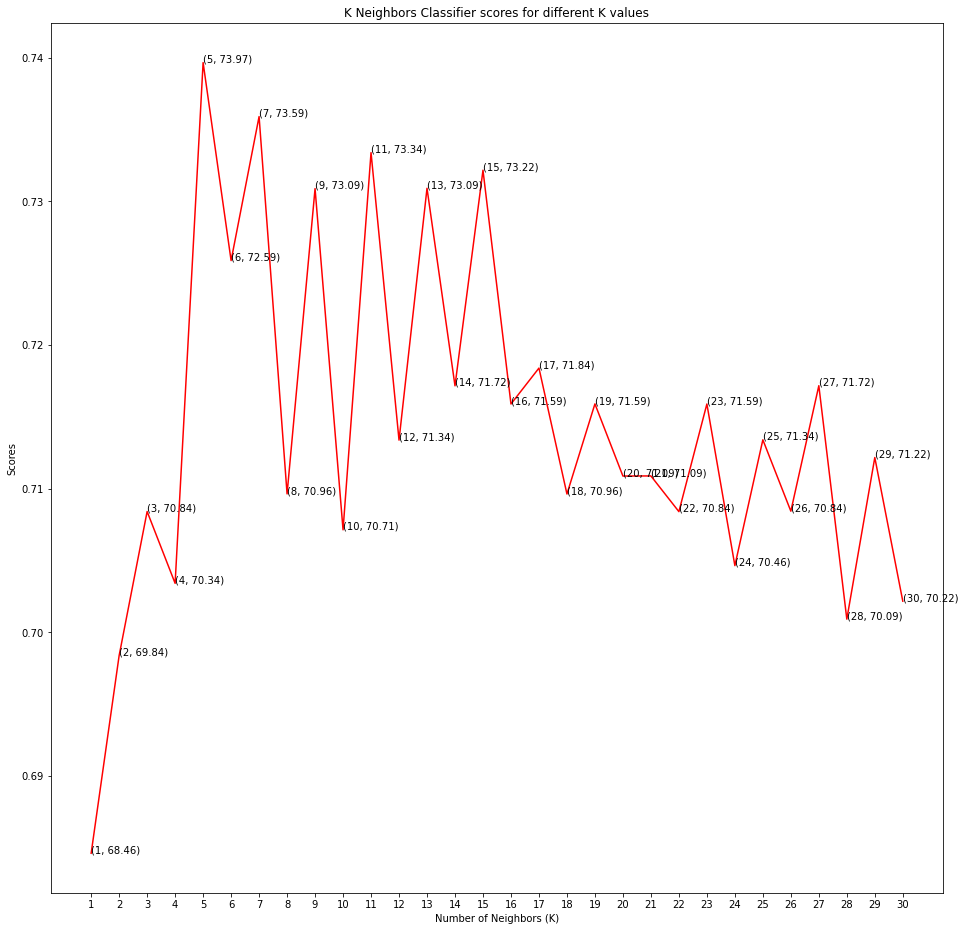

In [ ]:
plt.figure(figsize=(16,16))
plt.plot([k for k in range(1, 31)], knn_scores, color = 'red')
for i in range(1,31):
    plt.text(i, knn_scores[i-1], (i, round(knn_scores[i-1]*100,2)))
plt.xticks([i for i in range(1, 31)])
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Scores')
plt.title('K Neighbors Classifier scores for different K values')

In [ ]:
print('Accuracy score on Train data: {}'.format(knn_scores[4]*100))

Accuracy score on Train data: 73.96619496855345


In [ ]:
knn_classifier = KNeighborsClassifier(n_neighbors = 4)
pipe = make_pipeline(col_trans,knn_classifier)
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)
print('Accuracy score on Test Data: {}'.format(metrics.accuracy_score(y_test,y_pred)*100))

Accuracy score on Test Data: 69.5


##### c.	Evaluate the model built using Precision, Recall and F1 Score and what will be the optimization objective keeping in mind the problem statement. (5 marks) 

### 3. Decision Tree Classifier

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dt_scores = []
for i in range(1, len(X.columns) + 1):
    dt_classifier = DecisionTreeClassifier(max_features = i, random_state = 0)
    pipe = make_pipeline(col_trans,dt_classifier)
    dt_scores.append(cross_val_score(pipe, X_train, y_train, cv=5, scoring='accuracy').mean())

Text(0.5, 1.0, 'Decision Tree Classifier scores for different number of maximum features')

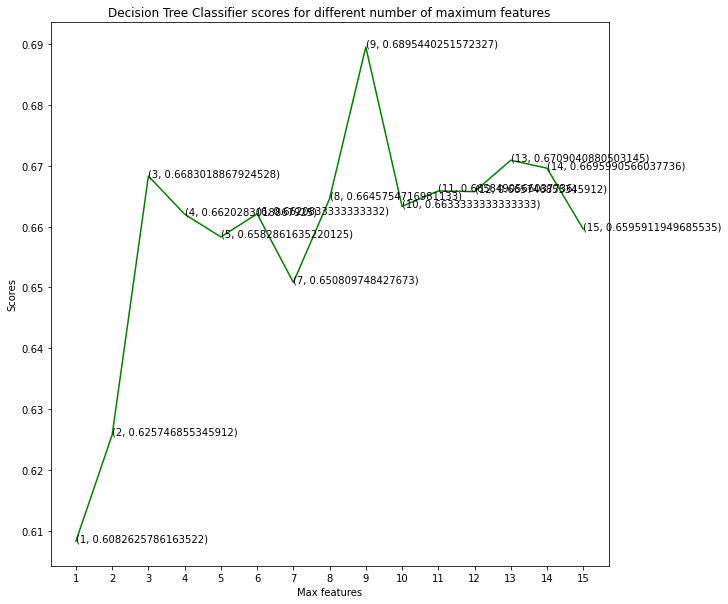

In [ ]:
plt.figure(figsize=(10,10))
plt.plot([i for i in range(1, len(X.columns) + 1)], dt_scores, color = 'green')
for i in range(1, len(X.columns) + 1):
    plt.text(i, dt_scores[i-1], (i, dt_scores[i-1]))
plt.xticks([i for i in range(1, len(X.columns) + 1)])
plt.xlabel('Max features')
plt.ylabel('Scores')
plt.title('Decision Tree Classifier scores for different number of maximum features')

In [ ]:
print('Accuracy score on Train data: {}'.format(dt_scores[3]*100))

Accuracy score on Train data: 66.20283018867926


In [ ]:
dt_classifier = DecisionTreeClassifier(max_features = 4, random_state = 0)
pipe = make_pipeline(col_trans,dt_classifier)
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)
print('Accuracy  score on Test data: {}'.format(metrics.accuracy_score(y_test,y_pred)*100))

Accuracy  score on Test data: 64.5


### 4. Random Forest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf_scores = []
estimators = [10, 100, 200, 500, 1000]
for i in estimators:
    rf_classifier = RandomForestClassifier(n_estimators = i, random_state = 0)
    pipe = make_pipeline(col_trans,rf_classifier)
    rf_scores.append(cross_val_score(pipe, X_train, y_train, cv=5, scoring='accuracy').mean())

In [ ]:
print('Accuracy score on Train data: {}'.format(rf_scores[4]*100))

Accuracy score on Train data: 77.97169811320754


In [ ]:
rf_classifier = RandomForestClassifier(n_estimators = 1000, random_state = 0)
pipe = make_pipeline(col_trans,rf_classifier)
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)
print('Accuracy score on Test data: {}'.format(metrics.accuracy_score(y_test,y_pred)*100))

Accuracy score on Test data: 79.5


##### d.	How do you improve the accuracy of the model? Write clearly the changes that you will make before re-fitting the model. Fit the final model.  (5 marks)

Random Forest performed well compared with other models. Let's run our model using Random Forest and have a look at its confusion matrix

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf_scores = []
estimators = [10, 100, 200, 500, 1000]
for i in estimators:
    rf_classifier = RandomForestClassifier(n_estimators = i, random_state = 0)
    pipe = make_pipeline(col_trans,rf_classifier)
    rf_scores.append(cross_val_score(pipe, X_train, y_train, cv=5, scoring='accuracy').mean())

In [ ]:
print('Accuracy score on Train data: {}'.format(rf_scores[4]*100))

Accuracy score on Train data: 77.97169811320754


In [ ]:
rf_classifier = RandomForestClassifier(n_estimators = 1000, random_state = 0)
pipe = make_pipeline(col_trans,rf_classifier)
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)
print('Accuracy score on Test data: {}'.format(metrics.accuracy_score(y_test,y_pred)*100))

Accuracy score on Test data: 79.5


Let's take a look at confusion matrix in out testing dataset

In [ ]:
print('Confusion Matrix - Testing Dataset')
print(pd.crosstab(y_test, y_pred, rownames = ['True'], colnames = ['Predicted'], margins = True))

Confusion Matrix - Testing Dataset
Predicted    0   1  All
True                   
0          108  10  118
1           31  51   82
All        139  61  200


In [ ]:
# Checking False Negative Rate
10/118

0.0847457627118644

8.47% of observations in testing data are misclassified as Benign

##### b.	What is the overall Accuracy? Please comment on whether it is good or not.  (3 mark)

### Precision, Recall and F1 Score

In [ ]:
from sklearn.metrics import precision_score,recall_score,f1_score
print('Precision Score: {}'.format(precision_score(y_test,y_pred)))
print('Recall Score: {}'.format(recall_score(y_test,y_pred)))
print('F1 Score: {}'.format(f1_score(y_test,y_pred)))

Precision Score: 0.8360655737704918
Recall Score: 0.6219512195121951
F1 Score: 0.7132867132867133


### Average Precision Score

In [ ]:
from sklearn.metrics import average_precision_score
average_precision = average_precision_score(y_test, y_pred)

print('Average precision-recall score: {0:0.2f}'.format(
      average_precision))

Average precision-recall score: 0.67


### ROC-AUC Score

In [ ]:
from sklearn.metrics import roc_auc_score
print('ROC AUC Score: {}'.format(roc_auc_score(y_test, y_pred)))

ROC AUC Score: 0.7686027284001654


### ROC Curve

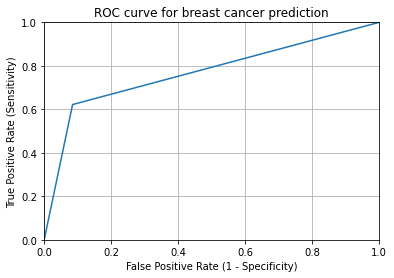

In [ ]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test,y_pred)
plt.plot(fpr, tpr)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.title('ROC curve for breast cancer prediction')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.grid(True)

##### e.	Write down a business interpretation/explanation of the model – which variables are affecting the target the most and explain the relationship. Feel free to use charts or graphs to explain. (2 marks)

You can improve the performance of the model to some more extent by performing Hyper parameter tuning in KNN, Random forest, etc.
